In [68]:
import pandas
d = pandas.read_csv("alpha_diversity.tsv", sep="\t")
d_orig = d.drop(["sample-id","Race", "AgeDayCat", "YrGp", "StCat", "Simpson", "Berger_Parker"], axis=1)
d_orig = d_orig.rename(columns={'Case_Cntl': 'Target'})
d_orig

,Target,Sex,DelivType,Abx,MilkType,ToxType,AgeMo,Shannon
0,Case,F,Vaginally,No,OB,A,5,2.237646
1,Case,M,Vaginally,No,OB,A,4,2.284147
2,Cntl,M,Unknown,No,HH,Neg,3,2.557874
3,Case,F,Vaginally,No,OF,B,4,2.642554
4,Cntl,F,Unknown,No,HH,Neg,3,1.646989
...,...,...,...,...,...,...,...,...
134,Case,F,Vaginally,No,OB,B,4,2.096171
135,Case,F,Vaginally,Yes,OF,A,1-2,1.642091
136,Case,F,Vaginally,No,OF,B,1-2,2.413304
137,Case,M,Vaginally,No,OB,B,1-2,2.420726


In [69]:
df = d_orig.drop(["Shannon"], axis=1)
df 

,Target,Sex,DelivType,Abx,MilkType,ToxType,AgeMo
0,Case,F,Vaginally,No,OB,A,5
1,Case,M,Vaginally,No,OB,A,4
2,Cntl,M,Unknown,No,HH,Neg,3
3,Case,F,Vaginally,No,OF,B,4
4,Cntl,F,Unknown,No,HH,Neg,3
...,...,...,...,...,...,...,...
134,Case,F,Vaginally,No,OB,B,4
135,Case,F,Vaginally,Yes,OF,A,1-2
136,Case,F,Vaginally,No,OF,B,1-2
137,Case,M,Vaginally,No,OB,B,1-2


In [34]:
#
# Multiple Association Analysis
#
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy import stats

def multiple_association_analysis(df):
    """
    Perform multiple association analysis on a pandas DataFrame.
    Column 1 is treated as the dependent variable; the remaining 6 as predictors.
    """
    y = df.iloc[:, 0]
    X = df.iloc[:, 1:]
    
    print("Dependent variable:", df.columns[0])
    print("Independent variables:", list(df.columns[1:]))
    print()

    # Detect whether dependent variable is numeric or categorical
    if pd.api.types.is_numeric_dtype(y):
        print("Detected numeric dependent variable → Performing linear regression\n")
        X = sm.add_constant(X)  # add intercept
        model = sm.OLS(y, X).fit()
        print(model.summary())
    
    else:
        print("Detected categorical dependent variable → Performing logistic regression\n")
        # Convert categorical y to numeric codes if needed
        #y_codes = pd.Categorical(y).codes
        #X = sm.add_constant(pd.get_dummies(X, drop_first=True))  # encode categorical predictors
        #model = sm.Logit(y_codes, X).fit(disp=False)
        #print(model.summary())

        # Optional: individual chi-square tests for association
        print("\nChi-square tests for individual associations:")
        for col in df.columns[1:]:
            contingency = pd.crosstab(y, df[col])
            chi2, p, dof, _ = stats.chi2_contingency(contingency)
            print(f"{col:20s}  chi2={chi2:8.3f}  p={p:8.5f}")

if __name__ == "__main__":
    multiple_association_analysis(df)


Dependent variable: Target
Independent variables: ['Sex', 'DelivType', 'Abx', 'MilkType', 'ToxType', 'AgeMo', 'Shannon']

Detected categorical dependent variable → Performing logistic regression


Chi-square tests for individual associations:
Sex                   chi2=   0.752  p= 0.38595
DelivType             chi2=  82.500  p= 0.00000
Abx                   chi2=   7.273  p= 0.02635
MilkType              chi2=  44.295  p= 0.00000
ToxType               chi2= 139.000  p= 0.00000
AgeMo                 chi2=  15.213  p= 0.00164
Shannon               chi2= 139.000  p= 0.46011


--- Sample Categorical Dataset Head ---
  Target Sex  DelivType Abx MilkType ToxType AgeMo
0   Case   F  Vaginally  No       OB       A     5
1   Case   M  Vaginally  No       OB       A     4
2   Cntl   M    Unknown  No       HH     Neg     3
3   Case   F  Vaginally  No       OF       B     4
4   Cntl   F    Unknown  No       HH     Neg     3

Target Distribution:
Target
Case    105
Cntl     34
Name: count, dtype: int64
---------------------------------------

          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              0.478        22.31%                     22.31%
1              0.259        12.10%                     34.41%


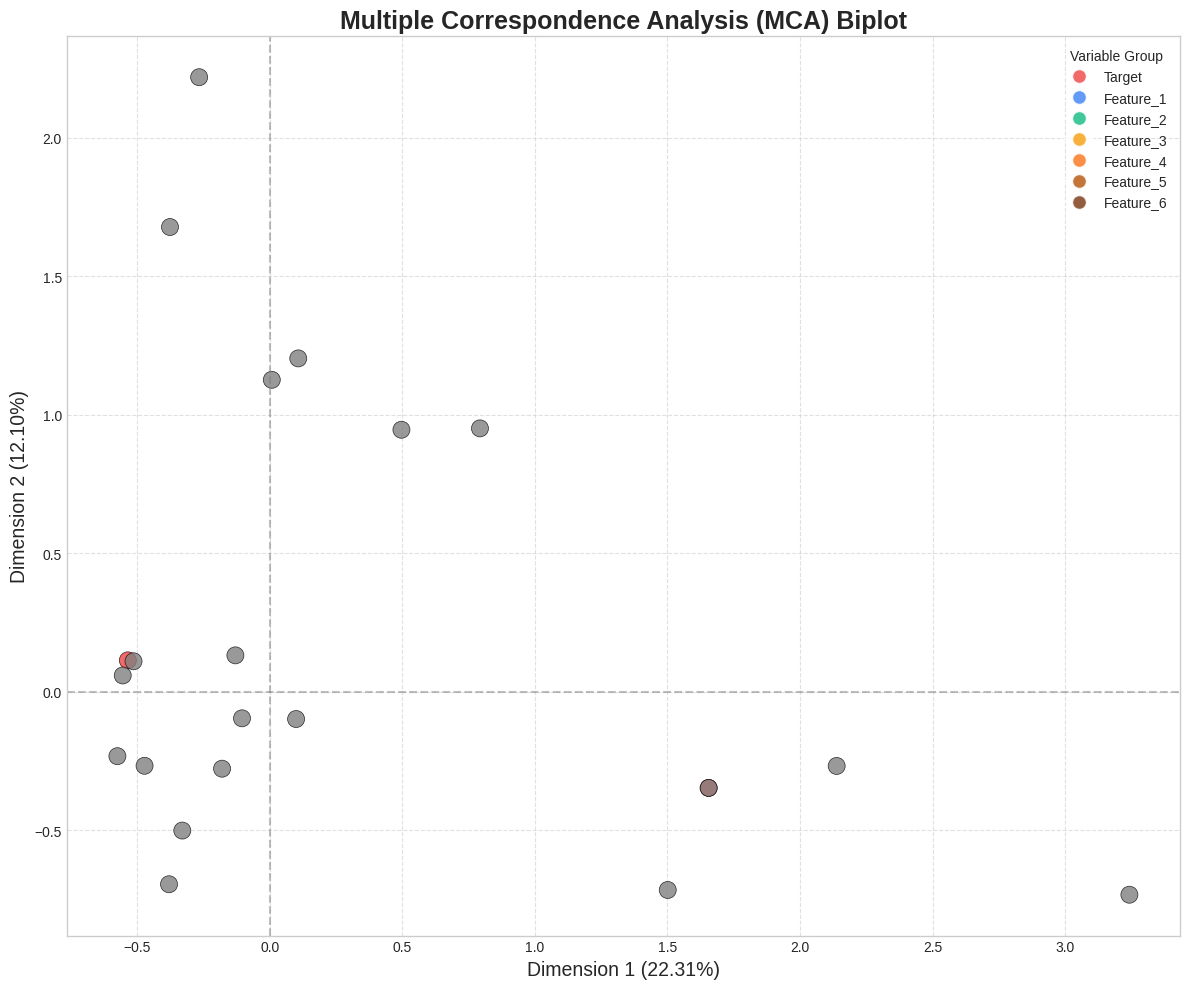



--- Interpretation Guide for MCA Biplot ---
1. Categories that are close to each other are strongly associated (frequently co-occur).
2. The 'case' and 'non-case' target categories are the most important points.
3. Check which feature categories cluster near the 'case' point to identify the strongest differentiators.
   - Example: If the category 'A' (of Feature_1) is very close to 'case' (of Target), it means 'A' is highly indicative of a 'case'.
4. Categories far from the center (0,0) have more discriminatory power than those clustered near the origin.

Component Explained Variance:
[22.311 12.1  ]
---------------------------------------



In [73]:
#
# Multiple Correspondence Analysis
#
import pandas as pd
import numpy as np
import prince
import matplotlib.pyplot as plt

# --- 1. print a header of the data
print("--- Sample Categorical Dataset Head ---")
print(df.head())
print("\nTarget Distribution:")
print(df['Target'].value_counts())
print("---------------------------------------\n")

# --- 2. Perform Multiple Correspondence Analysis (MCA) ---

# MCA requires all variables (including the target) to be included in the input DataFrame.
X = df.copy()

# Initialize MCA to reduce the dimensionality to 2 components
mca = prince.MCA(
    n_components=2,
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn'
)

# Fit and transform the data
mca = mca.fit(X)

print(mca.eigenvalues_summary)
mca.row_contributions_.head().style.format('{:.0%}')

# --- 3. Visualization (Using Matplotlib directly) ---

plt.rcParams['figure.figsize'] = (12, 10)
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 10))

# Get the coordinates of the categories (columns)
column_coords = mca.column_coordinates(X)

# Process the index to get the feature name (for coloring) and category label (for annotation)
# Index is typically formatted as 'FeatureName_CategoryValue' by prince
column_coords.index = column_coords.index.map(str) # Ensure indices are strings
column_coords['Feature'] = column_coords.index.str.split('_').str[0]
column_coords['Category'] = column_coords.index.str.split('_').str[1]
column_coords.columns = ['Dimension 1', 'Dimension 2', 'Feature', 'Category']

# Define a color map for clarity, focusing on the Target variable
color_map = {
    'Target': '#ef4444',
    'Feature_1': '#3b82f6',
    'Feature_2': '#10b981',
    'Feature_3': '#f59e0b',
    'Feature_4': '#f97316',
    'Feature_5': '#b45309',
    'Feature_6': '#78350f',
}

# Apply colors
column_coords['Color'] = column_coords['Feature'].map(color_map).fillna('gray')

# Scatter Plot
ax.scatter(
    column_coords['Dimension 1'],
    column_coords['Dimension 2'],
    c=column_coords['Color'],
    s=150, # Increased size for visibility
    alpha=0.8,
    edgecolors='black',
    linewidths=0.5
)

# Annotate points with category labels (more descriptive than just markers)
for i, row in column_coords.iterrows():
    ax.annotate(
        text=f"{row['Category']}", 
        xy=(row['Dimension 1'], row['Dimension 2']), 
        xytext=(5, 5), # Offset the text slightly
        textcoords='offset points', 
        fontsize=10, 
        fontweight='bold',
        color=row['Color']
    )

# Create a legend proxy (since we used scatter directly with colors)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=feature, markerfacecolor=color, markersize=10, alpha=0.8)
    for feature, color in color_map.items()
]
ax.legend(handles=legend_elements, title='Variable Group', loc='best', fontsize=10)


# Enhance plot titles and labels
ax.set_title('Multiple Correspondence Analysis (MCA) Biplot', fontsize=18, fontweight='bold')
ax.set_xlabel(f'Dimension 1 ({mca.percentage_of_variance_[0]:.2f}%)', fontsize=14)
ax.set_ylabel(f'Dimension 2 ({mca.percentage_of_variance_[1]:.2f}%)', fontsize=14)
plt.axhline(0, color='grey', linestyle='--', alpha=0.5)
plt.axvline(0, color='grey', linestyle='--', alpha=0.5)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- 4. Interpretation Guide ---

print("\n\n--- Interpretation Guide for MCA Biplot ---")
print("1. Categories that are close to each other are strongly associated (frequently co-occur).")
print("2. The 'case' and 'non-case' target categories are the most important points.")
print("3. Check which feature categories cluster near the 'case' point to identify the strongest differentiators.")
print("   - Example: If the category 'A' (of Feature_1) is very close to 'case' (of Target), it means 'A' is highly indicative of a 'case'.")
print("4. Categories far from the center (0,0) have more discriminatory power than those clustered near the origin.")
print("\nComponent Explained Variance:")
print(mca.percentage_of_variance_.round(3))
print("---------------------------------------\n")

In [63]:
 data = {
        'Target': np.random.choice(['Case', 'Non-Case'], size=100),
        'Age': np.random.normal(50, 10, 100),
        'BMI': np.random.normal(25, 4, 100),
        'Smoker': np.random.choice(['Yes', 'No'], size=100),
        'Alcohol': np.random.choice(['Yes', 'No'], size=100),
        'Sex': np.random.choice(['Male', 'Female'], size=100),
        'Exercise': np.random.normal(3, 1, 100),
        'Gene_Exp': np.random.normal(0, 1, 100)
    }
df = pd.DataFrame(data)
df.dtypes   

Target       object
Age         float64
BMI         float64
Smoker       object
Alcohol      object
Sex          object
Exercise    float64
Gene_Exp    float64
dtype: object

In [58]:
import pandas as pd
import numpy as np
import prince
import matplotlib.pyplot as plt

#print("--- Sample Categorical Dataset Head ---")
#print(df.head())
#print("\nTarget Distribution:")
#print(df['Target'].value_counts())
#print("---------------------------------------\n")
mca = prince.MCA(
    n_components=2,
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn'
)
X = df.copy()
mca = mca.fit(df)
#coords = mca.transform(X)
ax = mca.plot(df)
ax
# Plot the coordinates
#plt.figure(figsize=(8, 6))
#plt.scatter(coords.iloc[:, 0], coords.iloc[:, 1])
#plt.xlabel('Component 1')
#plt.ylabel('Component 2')
#plt.title('MCA Coordinates')
#plt.grid(True)
#plt.show()


alt.LayerChart(...)

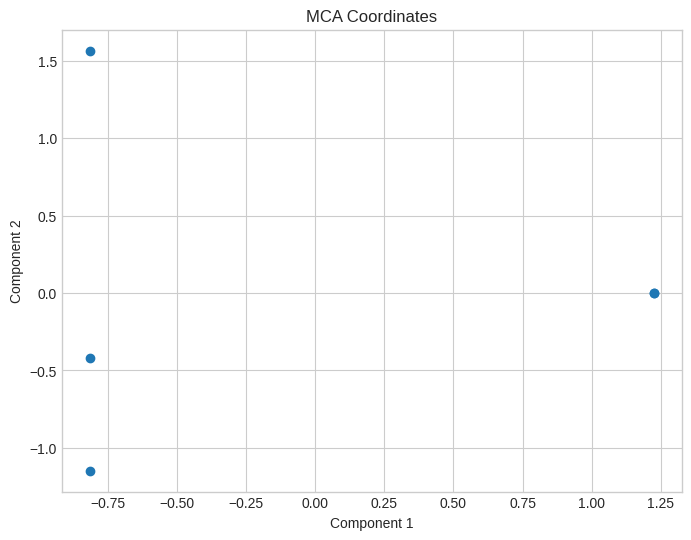

In [43]:
import pandas as pd
import prince
import matplotlib.pyplot as plt

# Sample data
data = {
    'Color': ['Red', 'Blue', 'Red', 'Green', 'Blue'],
    'Size': ['Small', 'Large', 'Medium', 'Small', 'Large'],
    'Action': ['Jump', 'Run', 'Jump', 'Walk', 'Run']
}
X = pd.DataFrame(data)

# Perform MCA
mca = prince.MCA(n_components=2)
mca = mca.fit(X)

# Get the transformed coordinates
coords = mca.transform(X)

# Plot the coordinates
plt.figure(figsize=(8, 6))
plt.scatter(coords.iloc[:, 0], coords.iloc[:, 1])
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title('MCA Coordinates')
plt.grid(True)
plt.show()

--- Sample Mixed Dataset Head (1 Continuous, 6 Categorical) ---
     Target Feature_1 Feature_2 Feature_3 Feature_4 Feature_5 Feature_6  \
0  non-case         B        No      High       Low    Medium       Low   
1  non-case         B        No    Medium      High    Medium    Medium   
2  non-case         B       Yes       Low    Medium      High    Medium   
3  non-case         C        No       Low       Low      High      High   
4      case         A       Yes    Medium      High    Medium      High   

   Continuous_Feature  
0            2.141383  
1           -0.750603  
2            0.830710  
3           -1.017324  
4           -0.115366  

Target Distribution:
Target
non-case    346
case        154
Name: count, dtype: int64
---------------------------------------



AttributeError: 'FAMD' object has no attribute 'continuous_variables_coordinates_'

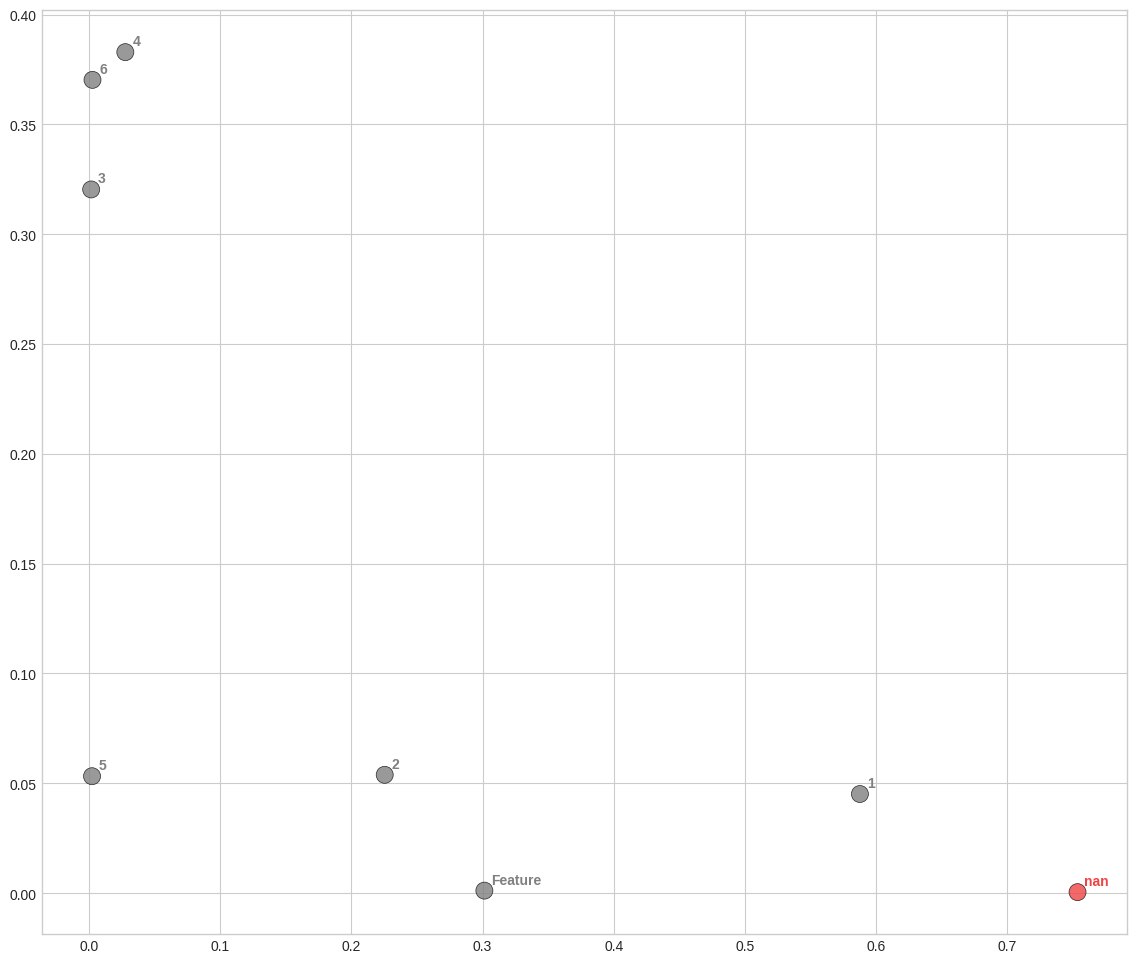

In [61]:
#
# FAMD analysis
#
import pandas as pd
import numpy as np
# NOTE: You will need to install the 'prince' library to run this script:
# pip install prince
import prince
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D # Used for custom legend

# --- 1. Generate Sample Mixed Data: 6 Categorical + 1 Continuous ---
np.random.seed(42)
N_SAMPLES = 500

# Create the Target variable (Binary)
target_values = np.random.choice(['case', 'non-case'], size=N_SAMPLES, p=[0.3, 0.7])

data = {}

# Feature 1 (Strong Categorical Association with 'case')
f1_choices = np.random.choice(['A', 'B', 'C'], size=N_SAMPLES, p=[0.2, 0.5, 0.3])
f1_choices[target_values == 'case'] = np.random.choice(['A', 'B', 'C'], 
                                                     size=np.sum(target_values == 'case'), 
                                                     p=[0.8, 0.1, 0.1])
data['Feature_1'] = f1_choices

# Feature 2 (Moderate Categorical Association)
f2_choices = np.random.choice(['Yes', 'No'], size=N_SAMPLES, p=[0.4, 0.6])
f2_choices[target_values == 'case'] = np.random.choice(['Yes', 'No'], 
                                                     size=np.sum(target_values == 'case'), 
                                                     p=[0.65, 0.35])
data['Feature_2'] = f2_choices

# Feature 3, 4, 5, 6 (Weak/No Categorical Association)
for i in range(3, 7):
    data[f'Feature_{i}'] = np.random.choice(['Low', 'Medium', 'High'], size=N_SAMPLES)

# --- NEW: Add the Continuous Feature ---
data['Continuous_Feature'] = np.random.randn(N_SAMPLES)
# Introduce association: 'case' observations have a higher mean value
data['Continuous_Feature'][target_values == 'case'] += 1.5


df = pd.DataFrame(data)
df.insert(0, 'Target', target_values)

print("--- Sample Mixed Dataset Head (1 Continuous, 6 Categorical) ---")
print(df.head())
print("\nTarget Distribution:")
print(df['Target'].value_counts())
print("---------------------------------------\n")

# --- 2. Perform Factor Analysis of Mixed Data (FAMD) ---

# FAMD is the appropriate method for datasets with both categorical and continuous variables.
X = df.copy()

# Initialize FAMD
famd = prince.FAMD(
    n_components=2,
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn'
)

# Fit and transform the data
famd = famd.fit(X)

# --- 3. Visualization (FAMD Biplot with Categorical Points and Continuous Vectors) ---

plt.rcParams['figure.figsize'] = (14, 12)
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, 12))

# --- PART A: Plot Categorical Coordinates (Points) ---

# Get the coordinates of the categories (columns)
column_coords = famd.column_coordinates_

# Process the index to get the feature name and category label
column_coords.index = column_coords.index.map(str)
column_coords['Feature'] = column_coords.index.str.split('_').str[0]
column_coords['Category'] = column_coords.index.str.split('_').str[1]
column_coords.columns = ['Dimension 1', 'Dimension 2', 'Feature', 'Category']

# Define a color map for clarity
color_map = {
    'Target': '#ef4444',    # Red for Target
    'Feature_1': '#3b82f6', # Blue
    'Feature_2': '#10b981', # Green
    'Feature_3': '#f59e0b', # Orange
    'Feature_4': '#f97316',
    'Feature_5': '#b45309',
    'Feature_6': '#78350f',
}

# Apply colors
column_coords['Color'] = column_coords['Feature'].map(color_map).fillna('gray')

# Scatter Plot: Categorical Categories
ax.scatter(
    column_coords['Dimension 1'],
    column_coords['Dimension 2'],
    c=column_coords['Color'],
    s=150, 
    alpha=0.8,
    edgecolors='black',
    linewidths=0.5
)

# Annotate points with category labels
for i, row in column_coords.iterrows():
    ax.annotate(
        text=f"{row['Category']}", 
        xy=(row['Dimension 1'], row['Dimension 2']), 
        xytext=(5, 5), 
        textcoords='offset points', 
        fontsize=10, 
        fontweight='bold',
        color=row['Color']
    )

# --- PART B: Plot Continuous Variable Coordinates (Vectors) ---

# Get coordinates for the continuous features (Correlation Circle)
continuous_coords = famd.continuous_variables_coordinates_
continuous_color = '#9333ea' # Purple for continuous features

for feature_name in continuous_coords.index:
    x_vec = continuous_coords.loc[feature_name, 'Dimension 1']
    y_vec = continuous_coords.loc[feature_name, 'Dimension 2']
    
    # Draw arrow from origin (0,0)
    ax.arrow(0, 0, x_vec, y_vec, 
             color=continuous_color, 
             head_width=0.03, 
             head_length=0.05, 
             linewidth=2, 
             length_includes_head=True, 
             alpha=0.7)
    
    # Label the arrow tip
    ax.annotate(
        text=feature_name,
        xy=(x_vec, y_vec),
        xytext=(x_vec * 1.05, y_vec * 1.05), # Offset label slightly
        color=continuous_color,
        fontsize=12,
        fontweight='bold'
    )

# Add a unit circle for better interpretation of continuous variables
circle = plt.Circle((0, 0), 1, color='darkgray', fill=False, linestyle='--', alpha=0.6)
ax.add_artist(circle)

# --- PART C: Final Plot Polish ---

# Determine axis limits to ensure all points and the unit circle fit
all_coords = pd.concat([column_coords.iloc[:, 0:2], continuous_coords.iloc[:, 0:2]])
max_abs = np.max(np.abs(all_coords.values.flatten()))
ax_limit = max(max_abs * 1.1, 1.1)
ax.set_xlim(-ax_limit, ax_limit)
ax.set_ylim(-ax_limit, ax_limit)
ax.set_aspect('equal', adjustable='box') 

# Create custom legend elements
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=feature, markerfacecolor=color, markersize=10, alpha=0.8)
    for feature, color in color_map.items()
]
# Add the continuous feature vector to the legend
legend_elements.append(Line2D([0], [0], color=continuous_color, lw=2, label='Continuous Vector (Correlation)'))
ax.legend(handles=legend_elements, title='Variable Group', loc='upper right', fontsize=10)


ax.set_title('Factor Analysis of Mixed Data (FAMD) Biplot', fontsize=18, fontweight='bold')
ax.set_xlabel(f'Dimension 1 ({famd.percentage_of_variance_[0]:.2f}%)', fontsize=14)
ax.set_ylabel(f'Dimension 2 ({famd.percentage_of_variance_[1]:.2f}%)', fontsize=14)
plt.axhline(0, color='grey', linestyle='--', alpha=0.5)
plt.axvline(0, color='grey', linestyle='--', alpha=0.5)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- 4. Interpretation Guide for FAMD ---

print("\n\n--- Interpretation Guide for FAMD Biplot ---")
print("1. CATEGORICAL POINTS (Dots): Categories close to each other frequently co-occur.")
print("   - Look for the 'case' and 'non-case' dots (Red) and see which other categories cluster near them.")
print("2. CONTINUOUS VECTORS (Arrows): Vectors show the direction and strength of correlation with the dimensions.")
print("   - Length: Longer arrows mean the variable is strongly represented by the 2 dimensions.")
print("   - Direction: The arrow points toward the categorical points it is most positively associated with.")
print("   - Example: If the 'Continuous_Feature' arrow points directly toward the 'case' dot, it means high values of that feature are strongly associated with the 'case' outcome.")
print("3. Discriminatory Power: Points/arrows farther from the center (0,0) are more important for separating the data.")
print("\nComponent Explained Variance:")
print(famd.percentage_of_variance_.round(3))
print("---------------------------------------\n")